# Plot Equilibrium Fractionation Factor Functions

In [1]:
import pathlib, sys, subprocess
import numpy as np

In [2]:
hostname = subprocess.check_output(["hostname"], text=True)
if "isotope3" in hostname:
    path_for_repo=f"/data37/kanon/modern_model_comparison/scripts"
elif "local" in hostname:
    path_for_repo=f"/Users/kanon/Work"
iso_model_dir = pathlib.Path(f"{path_for_repo}/IsoFracPy").resolve()
sys.path.append(str(iso_model_dir))

In [3]:
from IsotopeFractionationModel import (
    plot_eq_frac_factor,
    eq_frac_factor,
    prepare_combined_alpha_eq
)

In [4]:
def main():
    dt = 1 # Temperature step [K]
    temp_list = np.arange(250-273.15, 350-273.15, dt) # Range of temperature in °C
    plot_eq_frac_factor(
        temp_list, 
        temp_thres_min=-20,
        temp_thres_max=0
    )

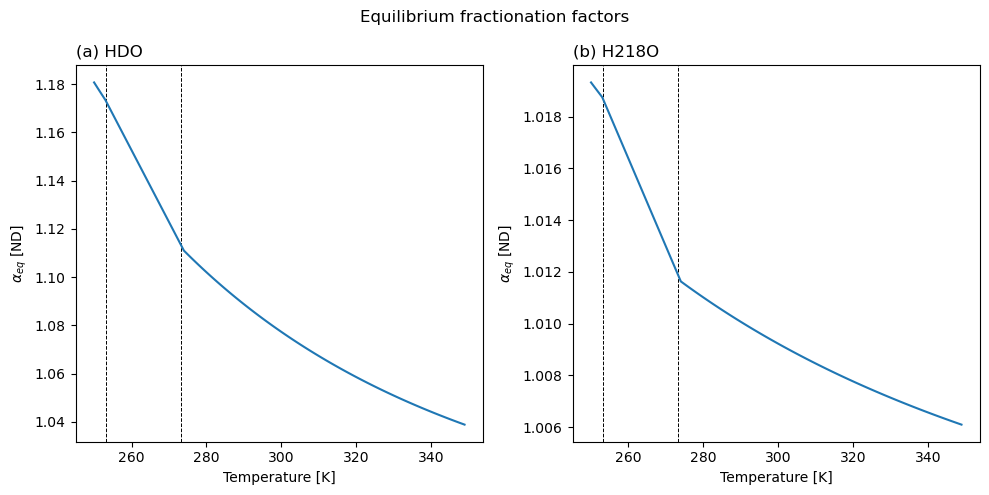

In [5]:
main()

In [6]:
help(eq_frac_factor)

Help on function eq_frac_factor in module IsotopeFractionationModel.EquilibriumFractionation:

eq_frac_factor(temp_C: float, ISO_TYPE: str = 'HDO', PHASE_TYPE: str = 'vl') -> float
    Calculate equilibrium fractionation factor for a given isotope type.
    
    Parameters:
    - temp_C (float): Temperature (°C).
    - ISO_TYPE (str): Isotope type, either "H218O" or "HDO". Default is "HDO".
    - PHASE_TYPE (str): Phase type, either "vl" (vapor -> liquid) or "vi" (vapor -> ice). 
      Default is "vl".
    
    Methods:
    - Validate `ISO_TYPE` and `PHASE_TYPE` using the `check_validity` function.
    - Convert the input temperature to Kelvin.
    - Calculate the equilibrium fractionation factor for specified `ISO_TYPE` and `PHASE_TYPE`.
    
    Returns:
    - float: Equilibrium fracionation factor (ND).
    
    Raises:
    - ValueError: If `PHASE_TYPE` is not "vl" or "vi".
    
    References:
    - This function uses the empirical equations of Majoube (1971a, 1971b).



In [7]:
help(prepare_combined_alpha_eq)

Help on function prepare_combined_alpha_eq in module IsotopeFractionationModel.EquilibriumFractionation:

prepare_combined_alpha_eq(temp_list: list, temp_thres_min: float = -20, temp_thres_max: float = 0, ISO_TYPE: str = 'HDO') -> list
    Prepare a combined list of equilibrium fractionation factors.
    
    Parameters:
    - temp_list (list): A list of temperature values (°C).
    - temp_thres_min (float): Minimum temperature threshold for the "vi" phase.
      Default is -20 °C.
    - temp_thres_max (float): Maximum temperature threshold for the "vl" phase.
      Default is 0 °C.
    - ISO_TYPE (str): Isotope type, either "H218O" or "HDO". Default is "HDO".
    
    Methods:
    - Validate `ISO_TYPE` using the `check_validity` function.
    - Calculate `alpha_eqi` (vapor -> ice) and `alpha_eql` (vapor -> liquid)
      for the given temperatures.
    - Combine the calculated values using linear interpolation between 
      `temp_thres_min` and `temp_thres_max`.
    
    Returns:
    